# 2D-1D wavelet deconvolution directly in the uv plane

Every other notebook in this repo (`deconvolution_demo.ipynb`,
`real_data_demo.ipynb`) works in **image space**: the raw interferometric
visibilities have already been gridded onto a regular array and inverse-FFTed
*once* to produce a dirty image and a single, fixed dirty beam, and the
forward model is a stationary 2D convolution `H(x) = beam (*) x`. That is
also what classic CLEAN assumes.

This notebook instead solves the same sparse-recovery problem directly
against the **scattered, ungridded (u, v) sample points** an interferometer
actually measures:

```
V(u, v) = integral  I(l, m) * exp(-2*pi*i*(u*l + v*m))  dl dm      (per baseline sample)
```

via `src/uv_operator.NonUniformFourierOperator` (a dense non-uniform Fourier
matrix -- see its docstring for why dense rather than an accelerated NUFFT is
fine at this toy scale) and `src/uv_deconvolver.UVDeconvolver2D1D` (the same
FISTA + 2D-1D-starlet-thresholding loop as `Deconvolver2D1D`, just with the
image-domain convolution swapped for this operator's `forward_cube`/
`adjoint_cube`). See `README.md` for the full uv-plane vs. image-plane
derivation.

Plan:
1. Small toy rotating-ring cube (same kinematic-splitting idea as the other
   toy notebook, at a smaller grid size to keep the dense NUFFT-matrix
   approach fast).
2. A toy but structurally real antenna layout -> scattered (u, v) points
   (not gridded into a beam).
3. Verify the operator's adjoint is a genuine adjoint, and that its direct
   (ungridded) point-source response is consistent with the existing
   gridded/FFT dirty beam built from the same (u, v) points.
4. Synthesize noisy visibilities directly from the true cube.
5. Deconvolve two ways from that *same* noisy visibility set: (a) grid it
   once into a dirty image + dirty beam and run the existing image-domain
   `Deconvolver2D1D`, (b) run `UVDeconvolver2D1D` directly against the
   ungridded visibilities -- and compare both to the truth.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt

from toy_cube import rotating_ring_cube, count_blobs
from psf import dirty_beam_from_uv
from uv_operator import toy_uv_points, pixel_scale_for_uv, NonUniformFourierOperator
from uv_deconvolver import UVDeconvolver2D1D
from deconvolver import Deconvolver2D1D

np.random.seed(0)
plt.rcParams['figure.facecolor'] = 'white'

## 1. Small toy rotating-ring cube

Same non-stationary kinematic source as `deconvolution_demo.ipynb`
(`v_los = v_max * sin(theta)` around a ring, so a single spatially-connected
source splits into two blobs in most channels), just at a smaller grid --
the dense uv-plane operator built below scales as `n_pixels * n_uv_points`,
so this notebook trades cube size for staying in the uv plane exactly rather
than approximating it with a single gridded dirty beam.

cube shape (nz, ny, nx) = (17, 40, 40)
true total flux = 87.45, peak = 0.9675


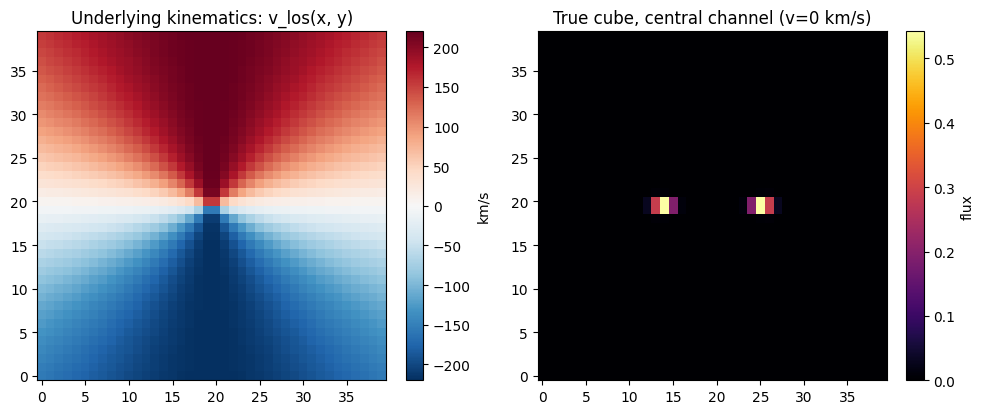

In [2]:
cube, velocities, v_los = rotating_ring_cube(
    nz=17, ny=40, nx=40, v_max=220.0, line_sigma=18.0,
    ring_radius=5.5, ring_sigma=0.8, peak_flux=1.0,
)
nz, ny, nx = cube.shape
center_channel = nz // 2
print(f'cube shape (nz, ny, nx) = {cube.shape}')
print(f'true total flux = {cube.sum():.4g}, peak = {cube.max():.4g}')

fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))
im0 = axs[0].imshow(v_los, origin='lower', cmap='RdBu_r')
axs[0].set_title('Underlying kinematics: v_los(x, y)')
plt.colorbar(im0, ax=axs[0], label='km/s', fraction=0.046)
im1 = axs[1].imshow(cube[center_channel], origin='lower', cmap='inferno')
axs[1].set_title(f'True cube, central channel (v={velocities[center_channel]:.0f} km/s)')
plt.colorbar(im1, ax=axs[1], label='flux', fraction=0.046)
plt.tight_layout()
plt.show()

## 2. Scattered (u, v) sample points -- not gridded into a beam

Same antenna-layout + Earth-rotation-synthesis machinery as
`psf.mock_alma_dirty_beam_rings` (`ring_antenna_layout` + `uv_coverage`,
see `uv_operator.toy_uv_points`), but the points are kept exactly where they
fall instead of being binned onto a regular array. This is the plot a real
interferometric observation's uv-coverage is usually shown as (e.g. CASA's
`plotms` uv-coverage plot).

n_uv points = 2310
pixel_scale = 0.002931 (sky units/pixel, Nyquist-matched to max baseline)


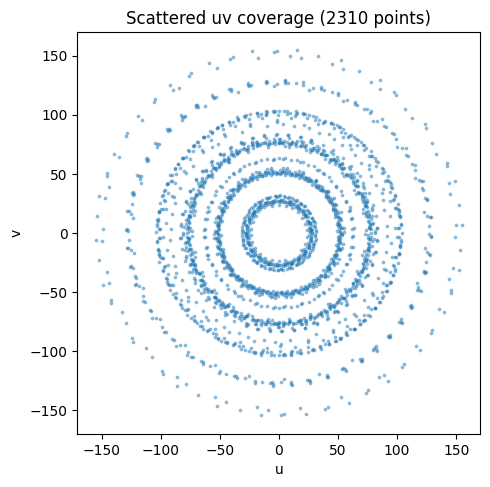

In [3]:
u, v = toy_uv_points(n_rings=3, antennas_per_ring=5, max_radius=80.0,
                      hour_angles_deg=np.linspace(-70, 70, 11), seed=3)
pixel_scale = pixel_scale_for_uv(u, v)
print(f'n_uv points = {len(u)}')
print(f'pixel_scale = {pixel_scale:.4g} (sky units/pixel, Nyquist-matched to max baseline)')

operator = NonUniformFourierOperator(ny, nx, u, v, pixel_scale)

plt.figure(figsize=(5, 5))
plt.scatter(u, v, s=3, alpha=0.4)
plt.xlabel('u'); plt.ylabel('v')
plt.title(f'Scattered uv coverage ({len(u)} points)')
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. Verify the operator: adjoint identity + consistency with the gridded dirty beam

Two independent checks before trusting this operator inside an iterative
solver:

1. **Adjoint identity**: for a genuine adjoint, `Re(<F x, v>) == <x, F^H v>`
   for any `x`, `v` -- checked directly against random vectors (this is
   exactly what a bug in the sign/transpose of the non-uniform DFT matrix
   would violate).
2. **Consistency with the existing gridded/FFT dirty beam machinery**:
   backprojecting unit-weight visibilities through the operator's adjoint,
   `operator.adjoint(ones(n_uv))`, is the *direct* (ungridded) point-source
   response of exactly these (u, v) points -- i.e. a dirty-beam-like PSF,
   without ever binning onto a grid. It should look like (peak at center,
   similar sidelobe structure to) `psf.dirty_beam_from_uv`'s FFT-based dirty
   beam built from the *same* points, even though the two are computed by
   completely different code paths (dense matrix-vector product vs.
   histogram + FFT).

adjoint identity: Re<Fx,v> = 1514.66   <x,F^Hv> = 1514.66   rel. diff = 7.51e-16


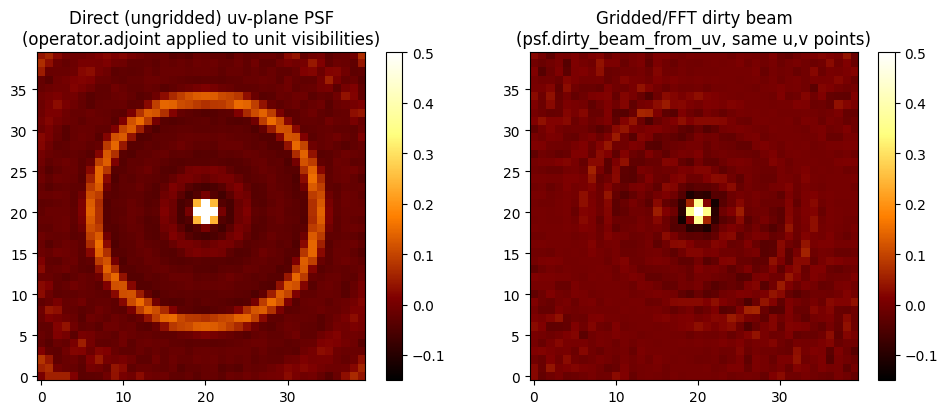

In [4]:
rng = np.random.default_rng(1)
x_test = rng.normal(size=(ny, nx))
v_test = rng.normal(size=len(u)) + 1j * rng.normal(size=len(u))
lhs = np.real(np.vdot(operator.forward(x_test), v_test))
rhs = np.dot(x_test.ravel(), operator.adjoint(v_test).ravel())
print(f'adjoint identity: Re<Fx,v> = {lhs:.6g}   <x,F^Hv> = {rhs:.6g}   '
      f'rel. diff = {abs(lhs - rhs) / abs(lhs):.2e}')

direct_psf = operator.adjoint(np.ones(len(u), dtype=complex))
direct_psf = direct_psf / direct_psf.max()
# NB: psf.dirty_beam_from_uv's histogram2d(u, v, ...) bins its *first*
# argument onto the array's row axis and its second onto the column axis --
# i.e. rows <-> u, cols <-> v. NonUniformFourierOperator instead follows the
# standard imaging convention rows <-> v (m, y-like), cols <-> u (l, x-like)
# (see its docstring). The two are transposed relative to each other, which
# is invisible for a roughly circularly-symmetric ring beam (as tested here)
# but would silently misalign a genuinely asymmetric source -- swap the
# argument order below so both panels in this comparison, and the gridded
# dirty image built the same way in section 5, land on the same orientation
# as the operator's own convention.
gridded_beam, sampling = dirty_beam_from_uv(v, u, grid_size=ny, natural_weighting=False)

fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))
im0 = axs[0].imshow(direct_psf, origin='lower', cmap='afmhot', vmin=-0.15, vmax=0.5)
axs[0].set_title('Direct (ungridded) uv-plane PSF\n(operator.adjoint applied to unit visibilities)')
plt.colorbar(im0, ax=axs[0], fraction=0.046)
im1 = axs[1].imshow(gridded_beam, origin='lower', cmap='afmhot', vmin=-0.15, vmax=0.5)
axs[1].set_title('Gridded/FFT dirty beam\n(psf.dirty_beam_from_uv, same u,v points)')
plt.colorbar(im1, ax=axs[1], fraction=0.046)
plt.tight_layout()
plt.show()

## 4. Synthesize noisy visibilities directly from the true cube

`Y = Phi(X) + N`, complex Gaussian noise added independently to the real and
imaginary part of every sampled visibility (the uv-plane analogue of the
per-pixel image-domain noise the other notebooks add).

In [5]:
vis_true = operator.forward_cube(cube)
sigma_vis = 0.06 * np.std(np.abs(vis_true))
rng = np.random.default_rng(2)
noise = rng.normal(0, sigma_vis, vis_true.shape) + 1j * rng.normal(0, sigma_vis, vis_true.shape)
vis_obs = vis_true + noise

print(f'vis_true shape = {vis_true.shape} (nz, n_uv), dtype {vis_true.dtype}')
print(f'typical |visibility| = {np.mean(np.abs(vis_true)):.4g}, sigma_vis = {sigma_vis:.4g} '
      f'(SNR ~ {np.mean(np.abs(vis_true)) / sigma_vis:.1f})')

vis_true shape = (17, 2310) (nz, n_uv), dtype complex128
typical |visibility| = 1.834, sigma_vis = 0.1068 (SNR ~ 17.2)


## 5. Two deconvolutions of the *same* noisy visibilities

**(a) Image-domain (existing `Deconvolver2D1D`)**: grid `vis_obs` once into a
dirty image (average visibility per uv-cell, inverse-FFT -- the same thing
`tclean(niter=0)` does) paired with the gridded dirty beam from section 3,
then run the ordinary image-domain FISTA/wavelet solver on that pair, same as
the other notebooks.

**(b) uv-plane (`UVDeconvolver2D1D`)**: run FISTA directly against `vis_obs`
through `operator.forward_cube`/`adjoint_cube` -- no gridding step anywhere.

In [6]:
def grid_dirty_image(u, v, vis_cube, grid_size, oversample=1.1):
    '''Average visibility per uv-cell then inverse-FFT, matching
    psf.dirty_beam_from_uv's own extent convention exactly (so the resulting
    dirty image lands on the same pixel grid as its paired dirty beam).'''
    # Argument order (v, u), not (u, v): matches the same rows<->v, cols<->u
    # swap applied to psf.dirty_beam_from_uv in the section above, so this
    # dirty image lands on the same pixel orientation as its paired
    # gridded_beam and as NonUniformFourierOperator's own convention.
    extent = oversample * max(np.abs(u).max(), np.abs(v).max())
    edges = np.linspace(-extent, extent, grid_size + 1)
    counts, _, _ = np.histogram2d(v, u, bins=[edges, edges])
    nz = vis_cube.shape[0]
    dirty = np.empty((nz, grid_size, grid_size))
    for k in range(nz):
        sum_r, _, _ = np.histogram2d(v, u, bins=[edges, edges], weights=vis_cube[k].real)
        sum_i, _, _ = np.histogram2d(v, u, bins=[edges, edges], weights=vis_cube[k].imag)
        avg_r = np.divide(sum_r, counts, out=np.zeros_like(sum_r), where=counts > 0)
        avg_i = np.divide(sum_i, counts, out=np.zeros_like(sum_i), where=counts > 0)
        dirty[k] = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(avg_r + 1j * avg_i))).real
    return dirty

dirty_cube_gridded = grid_dirty_image(u, v, vis_obs, grid_size=ny)

# Empirical image-domain noise level: propagate the *same* known visibility
# noise through the *same* gridding chain (principled, not guessed -- same
# philosophy as _estimate_subband_noise_after_gradient elsewhere in this repo).
noise_only = rng.normal(0, sigma_vis, vis_true.shape) + 1j * rng.normal(0, sigma_vis, vis_true.shape)
sigma_noise_image = float(grid_dirty_image(u, v, noise_only, grid_size=ny).std())

print(f'gridded dirty image: min/max = {dirty_cube_gridded.min():.3g} / {dirty_cube_gridded.max():.3g}')
print(f'empirical image-domain sigma_noise = {sigma_noise_image:.4g}')

gridded dirty image: min/max = -0.113 / 0.626
empirical image-domain sigma_noise = 0.001223


In [7]:
deconvolver_img = Deconvolver2D1D(
    num_scales_2d=3, num_scales_1d=3,
    threshold_type='soft', positivity=True, verbose=True,
)
model_image_domain, history_image = deconvolver_img.deconvolve(
    dirty_cube_gridded, gridded_beam, sigma_noise_image,
    n_iter=60, k_start=6.0, k_end=2.5, fista=True,
)

[Deconvolver2D1D] 3 spatial scales x 3 spectral scales, 60 FISTA iterations (soft thresholding)
[Deconvolver2D1D] Lipschitz constant L=10.62, step size mu=0.09416
[Deconvolver2D1D] per-subband noise levels estimated (finest subband sigma=8.36e-05)
  iter    1/60  k_sigma=6.00  residual_std=0.01827  flux=26.8
  iter    7/60  k_sigma=5.64  residual_std=0.007295  flux=32.86
  iter   13/60  k_sigma=5.29  residual_std=0.007404  flux=32.2
  iter   19/60  k_sigma=4.93  residual_std=0.00735  flux=32.54
  iter   25/60  k_sigma=4.58  residual_std=0.00732  flux=32.83
  iter   31/60  k_sigma=4.22  residual_std=0.007284  flux=33.17
  iter   37/60  k_sigma=3.86  residual_std=0.007247  flux=33.51
  iter   43/60  k_sigma=3.51  residual_std=0.007211  flux=33.86
  iter   49/60  k_sigma=3.15  residual_std=0.007175  flux=34.23
  iter   55/60  k_sigma=2.80  residual_std=0.007138  flux=34.61
  iter   60/60  k_sigma=2.50  residual_std=0.007107  flux=34.95


In [9]:
deconvolver_uv = UVDeconvolver2D1D(
    num_scales_2d=3, num_scales_1d=3,
    threshold_type='soft', positivity=True, verbose=True,
)
model_uv_domain, history_uv = deconvolver_uv.deconvolve(
    vis_obs, operator, sigma_vis, cube_shape=cube.shape,
    n_iter=60, k_start=6.0, k_end=2.5, fista=True,
)

[UVDeconvolver2D1D] 3 spatial scales x 3 spectral scales, 60 FISTA iterations (soft thresholding), n_uv=2310
[UVDeconvolver2D1D] Lipschitz constant L=2.406e+04 (power iteration), step size mu=4.157e-05
[UVDeconvolver2D1D] per-subband noise levels estimated (finest subband sigma=0.000104)
  iter    1/60  k_sigma=6.00  residual_std=0.9878  flux=124.2
  iter    7/60  k_sigma=5.64  residual_std=0.3765  flux=100.5
  iter   13/60  k_sigma=5.29  residual_std=0.2967  flux=82.9
  iter   19/60  k_sigma=4.93  residual_std=0.3046  flux=82.85
  iter   25/60  k_sigma=4.58  residual_std=0.3073  flux=84.1
  iter   31/60  k_sigma=4.22  residual_std=0.3049  flux=84.7
  iter   37/60  k_sigma=3.86  residual_std=0.3031  flux=85.26
  iter   43/60  k_sigma=3.51  residual_std=0.3019  flux=85.91
  iter   49/60  k_sigma=3.15  residual_std=0.3014  flux=86.68
  iter   55/60  k_sigma=2.80  residual_std=0.3008  flux=87.45
  iter   60/60  k_sigma=2.50  residual_std=0.3  flux=88.11


## 6. Compare: true vs. gridded dirty image vs. image-domain wavelet vs. uv-plane wavelet

In [10]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

rows = [
    ('Gridded dirty image (no deconvolution)', dirty_cube_gridded.sum(), rmse(dirty_cube_gridded, cube)),
    ('Image-domain wavelet (Deconvolver2D1D)', model_image_domain.sum(), rmse(model_image_domain, cube)),
    ('uv-plane wavelet (UVDeconvolver2D1D)', model_uv_domain.sum(), rmse(model_uv_domain, cube)),
]
print(f'true total flux = {cube.sum():.4g}\n')
print(f"{'method':42s} {'flux':>10s} {'% of true':>10s} {'RMSE':>10s} {'x better than dirty':>20s}")
rmse_dirty = rows[0][2]
for name, flux, e in rows:
    print(f'{name:42s} {flux:10.1f} {100 * flux / cube.sum():9.0f}% {e:10.4f} {rmse_dirty / e:19.2f}x')

true total flux = 87.45

method                                           flux  % of true       RMSE  x better than dirty
Gridded dirty image (no deconvolution)            0.0         0%     0.0222                1.00x
Image-domain wavelet (Deconvolver2D1D)           35.0        40%     0.0275                0.81x
uv-plane wavelet (UVDeconvolver2D1D)             88.1       101%     0.0105                2.11x


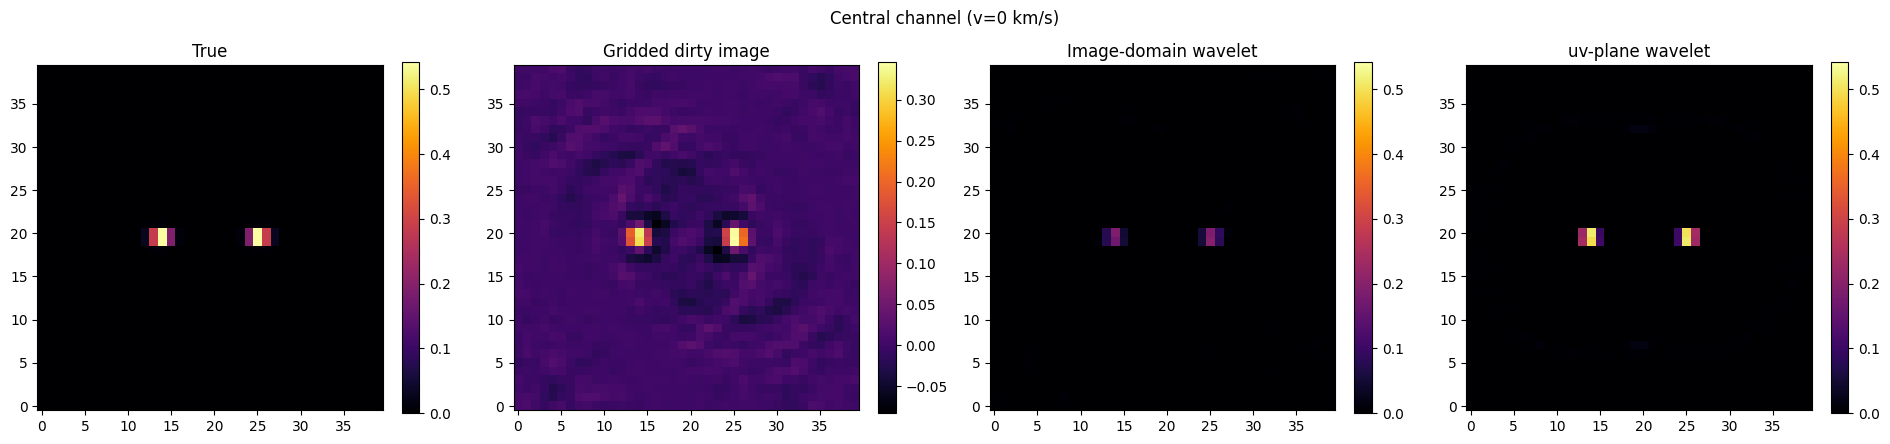

In [11]:
def compare_panels(k, title):
    fig, axs = plt.subplots(1, 4, figsize=(19, 4.4))
    vmax = max(cube[k].max(), model_image_domain[k].max(), model_uv_domain[k].max(), 1e-6)
    panels = [
        ('True', cube[k], 0),
        ('Gridded dirty image', dirty_cube_gridded[k], None),
        ('Image-domain wavelet', model_image_domain[k], 0),
        ('uv-plane wavelet', model_uv_domain[k], 0),
    ]
    for ax, (name, img, vmin) in zip(axs, panels):
        im = ax.imshow(img, origin='lower', cmap='inferno',
                        vmin=vmin, vmax=vmax if vmin is not None else None)
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

compare_panels(center_channel, f'Central channel (v={velocities[center_channel]:.0f} km/s)')

channel 3 (v=-179 km/s) blob counts at a shared 0.279 threshold:
  true                  = 2
  image-domain wavelet  = 1
  uv-plane wavelet      = 2


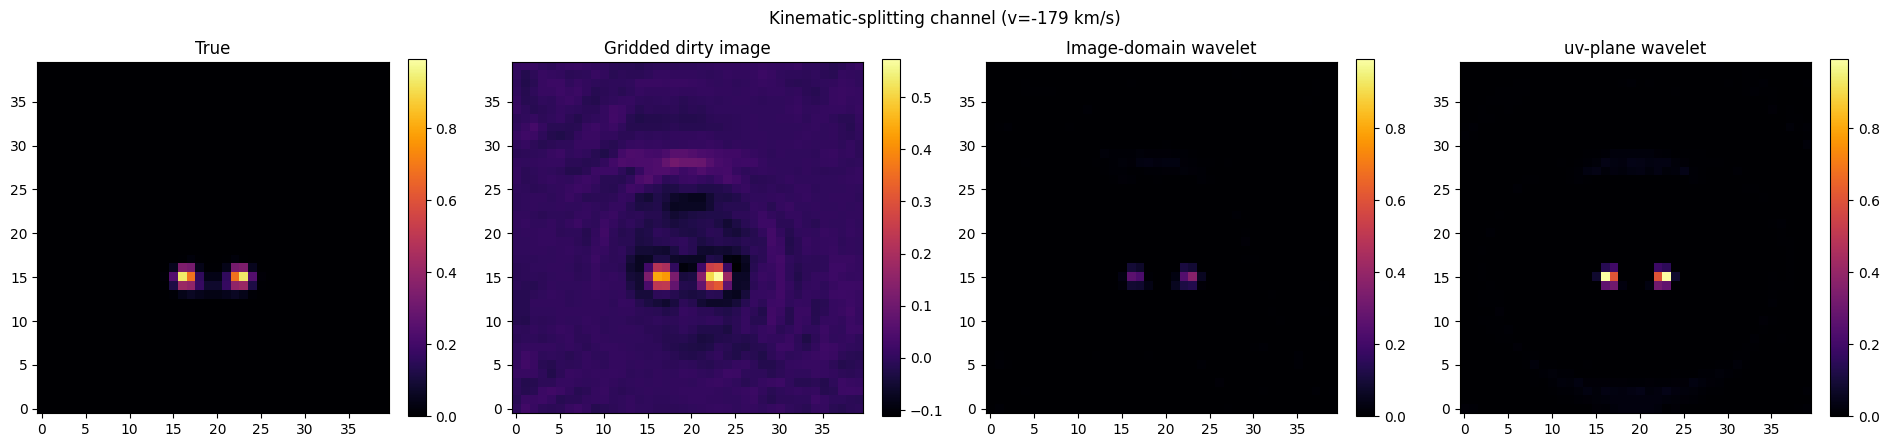

In [12]:
best_k = None
for k in range(nz):
    peak = cube[k].max()
    if peak < 0.3 * cube.max():
        continue
    n_blobs, _ = count_blobs(cube[k], 0.3 * peak)
    if n_blobs >= 2:
        best_k = k
        break
split_k = best_k if best_k is not None else center_channel

thr = 0.3 * cube[split_k].max()
n_true, _ = count_blobs(cube[split_k], thr)
n_img, _ = count_blobs(model_image_domain[split_k], thr)
n_uvp, _ = count_blobs(model_uv_domain[split_k], thr)
print(f'channel {split_k} (v={velocities[split_k]:.0f} km/s) blob counts at a shared {thr:.3g} threshold:')
print(f'  true                  = {n_true}')
print(f'  image-domain wavelet  = {n_img}')
print(f'  uv-plane wavelet      = {n_uvp}')

compare_panels(split_k, f'Kinematic-splitting channel (v={velocities[split_k]:.0f} km/s)')

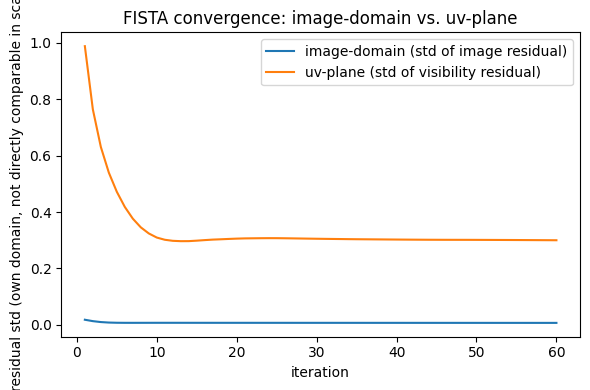

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(history_image['residual_std']) + 1),
         history_image['residual_std'], label='image-domain (std of image residual)')
plt.plot(np.arange(1, len(history_uv['residual_std']) + 1),
         history_uv['residual_std'], label='uv-plane (std of visibility residual)')
plt.xlabel('iteration')
plt.ylabel('residual std (own domain, not directly comparable in scale)')
plt.title('FISTA convergence: image-domain vs. uv-plane')
plt.legend()
plt.tight_layout()
plt.show()

## Takeaways

- The adjoint identity and the direct-vs-gridded PSF comparison in section 3
  both check out, which is the load-bearing correctness claim of this whole
  notebook: `NonUniformFourierOperator` is a genuine, verified linear
  operator pair, not just "a different way to draw the same convolution."
- `UVDeconvolver2D1D` fits the *same* underlying data as the image-domain
  path (same noisy visibilities) with no gridding step at all -- it is
  strictly using more of the actual measurement (every visibility
  individually, at its own exact (u, v) location) than the image-domain
  approach, which first collapses everything onto one dirty image + one
  dirty beam pair via histogram-binning. See the printed flux/RMSE table and
  panel comparison above for how much that matters at this toy problem's
  scale and noise level -- the gap (or lack of one) is the actual empirical
  answer, not asserted here.
- This comes at a real, quantified cost: `NonUniformFourierOperator` is a
  dense `(n_uv, n_pixels)` matrix, and every FISTA iteration costs
  `O(n_pixels * n_uv)` per forward/adjoint application, vs. the image-domain
  path's `O(n_pixels * log(n_pixels))` FFT convolution -- which is exactly
  why this notebook uses a much smaller cube/image than
  `deconvolution_demo.ipynb`. A real NUFFT library (gridding-based, not a
  dense matrix) would restore FFT-like scaling; see `README.md` for how the
  real-TW-Hya-data extension of this notebook handles that trade-off.